In [1]:
import igraph as ig
import numpy as np
from numpy.linalg import norm
import random
import pandas as pd
import scipy.io
import time
from IPython.display import display, clear_output
from operator import itemgetter
from SOINN import ASOINN
from SOINN import SOINN_plus
from SOINN import SOINN_plus_v2

# Dataset Importing

In [2]:
train = pd.read_csv('./NSL-KDD/KDDTrain+.txt', sep=',', header=None)
test = pd.read_csv('./NSL-KDD/KDDTest+.txt', sep=',', header=None)

# dropping first not necessary column
train.drop([0], axis=1, inplace=True)
test.drop([0], axis=1, inplace=True)

# shuffling training dataset
train = train.sample(frac=1).reset_index(drop=True)

# one-hot encoding for non-ordinal categorical variables (first three columns)
train = pd.get_dummies(train, columns=[1, 2, 3])
test = pd.get_dummies(test, columns=[1, 2, 3])

# adding columns present in train but not in test
extra_columns = []
for i in train.columns.values:
    if i not in test.columns.values:
        extra_columns.append(i)
for col in extra_columns:
    test[col] = 0

# reordering columns
train.columns.astype('string')
test.columns.astype('string')
cols = train.columns.tolist()
cols.sort()
train = train[cols]
test = test[cols]

y_train = train['41'].values
del train['41']
y_test = test['41'].values
del test['41']

# dropping the 'difficulty level' column
#del train['42']
#del test['42']

In [3]:
train.head()

,10,11,12,13,14,15,16,17,18,19,...,3_SF,3_SH,4,40,42,5,6,7,8,9
0,0,1,0,0,0,0,0,0,0,0,...,1,0,297,0.04,21,392,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,1,0,141,0.00,21,2713,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,1,0,35,0.00,19,130,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,1,0,298,0.00,21,805,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,1,0,249,0.00,21,3098,0,0,0,0


In [4]:
test.head()

,10,11,12,13,14,15,16,17,18,19,...,3_SF,3_SH,4,40,42,5,6,7,8,9
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1.00,21,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1.00,21,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,12983,0.00,21,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,20,0.00,15,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0.71,11,15,0,0,0,0


# ASOINN

## Training

In [5]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values

s = ASOINN.ASOINN(x1, x2, lambda_iter=100, max_edge_age=50)

start_time = time.time()

for index, row in train.iterrows():
    x = row.values
    y = y_train[index]
    s.fit_input_signal(x, y)
    # print completed percentage
    percent_completed = round((index / len(train))*100, 2)
    if index % 100 == 0 or index == len(train):
        clear_output(wait=True)
        print(f'Processing input {index}: {percent_completed}% completed')

finish_time = round(time.time() - start_time)
mins = round(finish_time / 60)
secs = finish_time % 60

clear_output(wait=True)
print(f'Training time: {mins} min {secs} sec')
print(f'Inputs processed: {index}')

n_v = s.network.vcount()
n_e = s.network.ecount()
print(f'Number of nodes: {n_v}')
print(f'Number of edges: {n_e}')

Training time: 4 min 42 sec
Inputs processed: 125972
Number of nodes: 149
Number of edges: 141


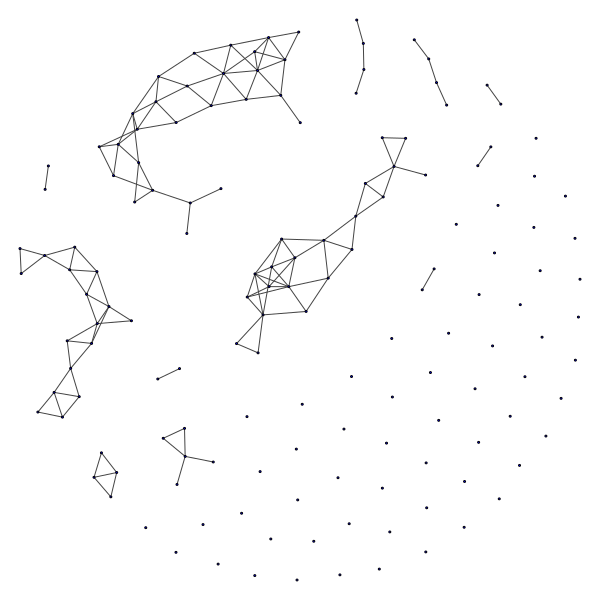

In [6]:
s.network.layout(layout='kk')
ig.plot(s.network, vertex_size=2, vertex_color=['blue'])

## Testing

In [7]:
n_errors = 0
n_false_alarms = 0
n_non_detected_attacks = 0
predicted = []

for index, row in test.iterrows():
    x = row.values
    y = y_test[index]
    yp = s.predict(x)
    # append predicted label for later visualization
    predicted.append(yp)
    if y != yp:
        n_errors += 1
    if y != yp and (y == 'normal' and yp != 'normal'):
        n_false_alarms += 1
    if y != yp and (y != 'normal' and yp == 'normal'):
        n_non_detected_attacks += 1
    # print completed percentage
    percent_completed = round((index / len(test))*100, 2)
    if index % 100 == 0 or index == len(test):
        clear_output(wait=True)
        print(f'Predictions completed: {percent_completed}%')

clear_output(wait=True)
print(f'Inputs processed: {index}')
p1 = round((1 - (n_errors / index))*100, 2)
p2 = round((n_false_alarms / index)*100, 2)
p3 = round((1 - (n_non_detected_attacks / index))*100, 2)
print(f'Overall accuracy: {p1}%')
print(f'False alarms: {p2}%')
print(f'Detected attacks: {p3}%')

Inputs processed: 22543
Overall accuracy: 63.53%
False alarms: 2.27%
Detected attacks: 80.51%


In [8]:
print('PREDICTION ERRORS')
errors_freq = dict()
for i in range(len(y_test)):
    if y_test[i] != predicted[i]:
        errors_freq[f'{y_test[i]}-{predicted[i]}'] = 0

for i in range(len(y_test)):
    if y_test[i] != predicted[i]:
        #print(f'Prediction given {y_test[i]}: {predicted[i]}')
        errors_freq[f'{y_test[i]}-{predicted[i]}'] += 1

# sort frequency dictionary
errors_freq = dict(sorted(errors_freq.items(), key=itemgetter(1))) 
errors_freq

PREDICTION ERRORS


{'sendmail-portsweep': 1,
 'warezmaster-nmap': 1,
 'teardrop-ipsweep': 1,
 'imap-normal': 1,
 'udpstorm-neptune': 1,
 'ftp_write-portsweep': 1,
 'phf-neptune': 1,
 'phf-normal': 1,
 'teardrop-portsweep': 1,
 'udpstorm-portsweep': 1,
 'loadmodule-normal': 2,
 'worm-normal': 2,
 'buffer_overflow-warezclient': 2,
 'rootkit-neptune': 2,
 'perl-normal': 2,
 'sqlattack-normal': 2,
 'ftp_write-normal': 2,
 'xterm-warezclient': 2,
 'saint-satan': 3,
 'sendmail-neptune': 3,
 'snmpguess-neptune': 3,
 'neptune-ipsweep': 3,
 'multihop-neptune': 4,
 'neptune-portsweep': 4,
 'neptune-satan': 4,
 'saint-portsweep': 4,
 'named-neptune': 4,
 'xsnoop-normal': 4,
 'normal-nmap': 5,
 'satan-portsweep': 5,
 'land-neptune': 7,
 'httptunnel-warezclient': 8,
 'xlock-normal': 9,
 'sendmail-normal': 10,
 'teardrop-neptune': 10,
 'ipsweep-normal': 11,
 'xterm-normal': 11,
 'rootkit-normal': 11,
 'named-normal': 13,
 'warezmaster-portsweep': 13,
 'multihop-normal': 14,
 'ps-normal': 15,
 'httptunnel-normal': 16,


# SOINN+

## Training

In [9]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x3 = train.iloc[rand_int].values

s = SOINN_plus.SOINN_plus(x1, x2, x3)

start_time = time.time()

for index, row in train.iterrows():
    x = row.values
    y = y_train[index]
    s.fit_input_signal(x, y)
    # print completed percentage
    percent_completed = round((index / len(train))*100, 2)
    if index % 100 == 0 or index == len(train):
        clear_output(wait=True)
        print(f'Processing input {index}: {percent_completed}% completed')

finish_time = round(time.time() - start_time)
mins = round(finish_time / 60)
secs = finish_time % 60

clear_output(wait=True)
print(f'Training time: {mins} min {secs} sec')
print(f'Inputs processed: {index}')

n_v = s.network.vcount()
n_e = s.network.ecount()
print(f'Number of nodes: {n_v}')
print(f'Number of edges: {n_e}')

Training time: 4 min 11 sec
Inputs processed: 125972
Number of nodes: 315
Number of edges: 154


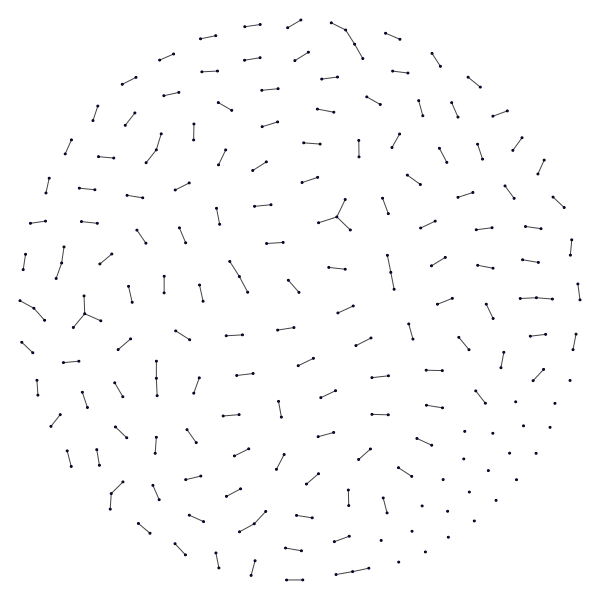

In [10]:
ig.plot(s.network, vertex_size=2, vertex_color=['blue'])

## Testing

In [11]:
n_errors = 0
n_false_alarms = 0
n_non_detected_attacks = 0
predicted = []

for index, row in test.iterrows():
    x = row.values
    y = y_test[index]
    yp = s.predict(x)
    # append predicted label for later visualization
    predicted.append(yp)
    if y != yp:
        n_errors += 1
    if y != yp and (y == 'normal' and yp != 'normal'):
        n_false_alarms += 1
    if y != yp and (y != 'normal' and yp == 'normal'):
        n_non_detected_attacks += 1
    # print completed percentage
    percent_completed = round((index / len(test))*100, 2)
    if index % 100 == 0 or index == len(test):
        clear_output(wait=True)
        print(f'Predictions completed: {percent_completed}%')

clear_output(wait=True)
print(f'Inputs processed: {index}')
p1 = round((1 - (n_errors / index))*100, 2)
p2 = round((n_false_alarms / index)*100, 2)
p3 = round((1 - (n_non_detected_attacks / index))*100, 2)
print(f'Overall accuracy: {p1}%')
print(f'False alarms: {p2}%')
print(f'Detected attacks: {p3}%')

Inputs processed: 22543
Overall accuracy: 68.31%
False alarms: 2.28%
Detected attacks: 82.54%


In [12]:
print('PREDICTION ERRORS')
errors_freq = dict()
for i in range(len(y_test)):
    if y_test[i] != predicted[i]:
        errors_freq[f'{y_test[i]}-{predicted[i]}'] = 0

for i in range(len(y_test)):
    if y_test[i] != predicted[i]:
        #print(f'Prediction given {y_test[i]}: {predicted[i]}')
        errors_freq[f'{y_test[i]}-{predicted[i]}'] += 1

# sort frequency dictionary
errors_freq = dict(sorted(errors_freq.items(), key=itemgetter(1))) 
errors_freq

PREDICTION ERRORS


{'rootkit-neptune': 1,
 'ftp_write-satan': 1,
 'imap-normal': 1,
 'httptunnel-satan': 1,
 'multihop-satan': 1,
 'ftp_write-ipsweep': 1,
 'normal-smurf': 1,
 'httptunnel-back': 1,
 'ftp_write-normal': 1,
 'warezmaster-satan': 1,
 'rootkit-satan': 1,
 'loadmodule-normal': 2,
 'ipsweep-portsweep': 2,
 'worm-normal': 2,
 'sendmail-portsweep': 2,
 'xlock-back': 2,
 'perl-normal': 2,
 'rootkit-back': 2,
 'satan-ipsweep': 2,
 'land-portsweep': 2,
 'sqlattack-normal': 2,
 'udpstorm-normal': 2,
 'phf-normal': 2,
 'neptune-portsweep': 2,
 'named-back': 3,
 'satan-normal': 3,
 'neptune-satan': 3,
 'ps-satan': 3,
 'warezmaster-nmap': 3,
 'teardrop-portsweep': 3,
 'teardrop-neptune': 3,
 'portsweep-ipsweep': 3,
 'named-pod': 3,
 'multihop-portsweep': 4,
 'teardrop-normal': 4,
 'neptune-ipsweep': 4,
 'xsnoop-normal': 4,
 'neptune-teardrop': 5,
 'warezmaster-neptune': 5,
 'land-normal': 5,
 'satan-portsweep': 6,
 'saint-normal': 6,
 'guess_passwd-portsweep': 6,
 'xlock-normal': 7,
 'back-normal': 8,


# SOINN v2

## Training

In [13]:
rand_int = random.randint(1, len(train) - 1)
x1 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x2 = train.iloc[rand_int].values
rand_int = random.randint(1, len(train) - 1)
x3 = train.iloc[rand_int].values

s = SOINN_plus_v2.SOINN_plus(x1, x2, x3)

start_time = time.time()

for index, row in train.iterrows():
    x = row.values
    y = y_train[index]
    s.fit_input_signal(x, y)
    # print completed percentage
    percent_completed = round((index / len(train))*100, 2)
    if index % 100 == 0 or index == len(train):
        clear_output(wait=True)
        print(f'Processing input {index}: {percent_completed}% completed')

finish_time = round(time.time() - start_time)
mins = round(finish_time / 60)
secs = finish_time % 60

clear_output(wait=True)
print(f'Training time: {mins} min {secs} sec')
print(f'Inputs processed: {index}')

n_v = s.network.vcount()
n_e = s.network.ecount()
print(f'Number of nodes: {n_v}')
print(f'Number of edges: {n_e}')

Training time: 15 min 5 sec
Inputs processed: 125972
Number of nodes: 1362
Number of edges: 593


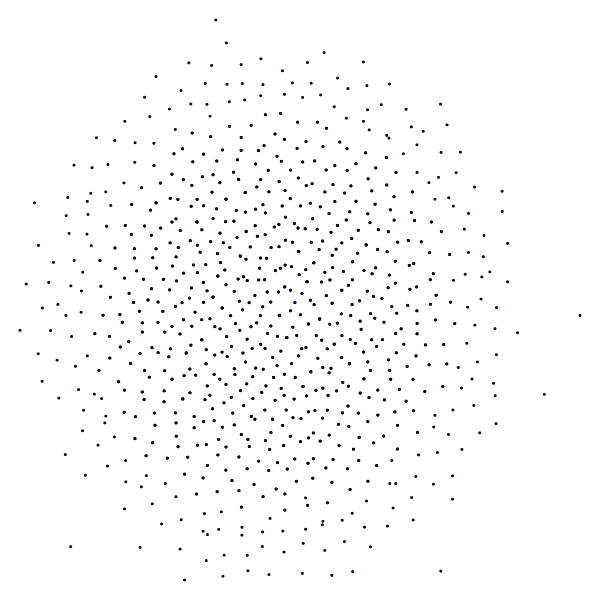

In [14]:
s.network.layout(layout='kk')
ig.plot(s.network, vertex_size=2, vertex_color=['blue'])

## Testing

In [15]:
n_errors = 0
n_false_alarms = 0
n_non_detected_attacks = 0
predicted = []

for index, row in test.iterrows():
    x = row.values
    y = y_test[index]
    yp = s.predict(x)
    # append predicted label for later visualization
    predicted.append(yp)
    if y != yp:
        n_errors += 1
    if y != yp and (y == 'normal' and yp != 'normal'):
        n_false_alarms += 1
    if y != yp and (y != 'normal' and yp == 'normal'):
        n_non_detected_attacks += 1
    # print completed percentage
    percent_completed = round((index / len(test))*100, 2)
    if index % 100 == 0 or index == len(test):
        clear_output(wait=True)
        print(f'Predictions completed: {percent_completed}%')

clear_output(wait=True)
print(f'Inputs processed: {index}')
p1 = round((1 - (n_errors / index))*100, 2)
p2 = round((n_false_alarms / index)*100, 2)
p3 = round((1 - (n_non_detected_attacks / index))*100, 2)
print(f'Overall accuracy: {p1}%')
print(f'False alarms: {p2}%')
print(f'Detected attacks: {p3}%')

Inputs processed: 22543
Overall accuracy: 69.0%
False alarms: 1.67%
Detected attacks: 82.37%


In [16]:
print('PREDICTION ERRORS')
errors_freq = dict()
for i in range(len(y_test)):
    if y_test[i] != predicted[i]:
        errors_freq[f'{y_test[i]}-{predicted[i]}'] = 0

for i in range(len(y_test)):
    if y_test[i] != predicted[i]:
        #print(f'Prediction given {y_test[i]}: {predicted[i]}')
        errors_freq[f'{y_test[i]}-{predicted[i]}'] += 1

# sort frequency dictionary
errors_freq = dict(sorted(errors_freq.items(), key=itemgetter(1))) 
errors_freq

PREDICTION ERRORS


{'sendmail-satan': 1,
 'buffer_overflow-warezclient': 1,
 'rootkit-satan': 1,
 'rootkit-back': 1,
 'portsweep-satan': 1,
 'imap-normal': 1,
 'udpstorm-ipsweep': 1,
 'ipsweep-portsweep': 1,
 'warezmaster-teardrop': 1,
 'httptunnel-back': 1,
 'multihop-satan': 1,
 'rootkit-nmap': 1,
 'udpstorm-portsweep': 1,
 'httptunnel-warezclient': 1,
 'satan-normal': 2,
 'loadmodule-normal': 2,
 'neptune-teardrop': 2,
 'warezmaster-portsweep': 2,
 'worm-normal': 2,
 'xlock-back': 2,
 'perl-normal': 2,
 'land-portsweep': 2,
 'sqlattack-normal': 2,
 'warezmaster-back': 2,
 'phf-normal': 2,
 'httptunnel-nmap': 2,
 'satan-ipsweep': 2,
 'teardrop-neptune': 2,
 'named-back': 3,
 'sendmail-ipsweep': 3,
 'snmpguess-ipsweep': 3,
 'teardrop-ipsweep': 3,
 'warezmaster-satan': 3,
 'ftp_write-normal': 3,
 'named-pod': 3,
 'ipsweep-normal': 4,
 'named-ipsweep': 4,
 'xsnoop-normal': 4,
 'saint-nmap': 5,
 'teardrop-normal': 5,
 'land-ipsweep': 5,
 'pod-normal': 6,
 'processtable-portsweep': 6,
 'saint-normal': 6,
 '